# Exploration and cleaning of data from dbCAN-PUL

In [ ]:
import polars
import matplotlib.pyplot as plt
import numpy as np
import gb_io
from Bio import Entrez
from Bio import Blast
import json

EMAIL = 'b.rosenthal@lumc.com'
Blast.email = EMAIL
Entrez.email = EMAIL

In [ ]:
# Entrez utility functions
def request_summary(acc, db="nuccore"):
    handle = Entrez.esummary(
        db=db,
        id=acc,
        retmode="json"
    )
    record = handle.read()
    handle.close()
    # parse the JSON response to get the sequence length
    record = json.loads(record)
    return record

def request_sequence(acc, db="nuccore"):
    handle = Entrez.efetch(
        db=db,
        id=acc,
        rettype="gb",
        retmode="json",
        complexity=1
    )
    record = handle.read()
    handle.close()
    return record

## Get initial cluster table

### Data from dbCAN-PUL
Only removing the accession ID of the master record for WGS contigs, which is everything after the first space.

In [80]:
# load cluster file (dbCAN)
cluster_path = '../data/dbCAN-PUL_Feb-2025.xlsx'

def clean_cluster_table(cluster_path: str) -> polars.DataFrame:
    # read dbCAN PUL annotations from excel sheet
    pul_annotations = polars.read_excel(cluster_path).select(['ID', 'genomic_accession_number', 'nucleotide_position_range', 'ncbi_species_tax_id'])
    # add a column for the start and end positions of the PULs
    pul_annotations = pul_annotations.with_columns([
        polars.col('nucleotide_position_range').map_elements(lambda x: int(x.split(',')[0].split('-')[0]), return_dtype=polars.Int64).alias('start'),
        polars.col('nucleotide_position_range').map_elements(lambda x: int(x.split(',')[0].split('-')[1]), return_dtype=polars.Int64).alias('end'),
        polars.col('genomic_accession_number').map_elements(lambda x: x.split('.')[0].strip()).alias('sequence_id'),
        polars.col('ID').map_elements(lambda x: x.strip()).alias('cluster_id'),
        polars.col('ncbi_species_tax_id').map_elements(lambda x: int(x), return_dtype=polars.Int64).alias('tax_id'),
    ]).sort('sequence_id')
    return pul_annotations.select(['sequence_id', 'cluster_id', 'start', 'end', 'tax_id'])

cluster_table = clean_cluster_table(cluster_path)
display(cluster_table.head(5))

sequence_id,cluster_id,start,end,tax_id
str,str,i64,i64,i64
"""AAXF02000034""","""PUL0415""",53978,62950,28116
"""AAXF02000045""","""PUL0416""",159078,179453,28116
"""AAXF02000045""","""PUL0417""",182417,201731,28116
"""AAXF02000047""","""PUL0167""",109596,128600,28116
"""AAXF02000047""","""PUL0178""",106585,128684,28116


Two accession IDs are somewhat problematic: `Ga0139390_150` and `ADWO01000020`. 

`Ga0139390_150` is not a genbank/ncbi accession ID, but from a DOE-JGI GOLD entry https://gold.jgi.doe.gov/analysis_project?id=Ga0139390. Downloading the genome requires an orchid ID. Based on NCBI taxon ID, 749906 this could also be investigated further at https://www.ncbi.nlm.nih.gov/bioproject/301235.

The second is from a PUL entry in dbCAN-PUL that spans over 2 contigs from the same WGS master record (saved as `ADWO01000021.1, ADWO01000020.1`). Initial handling of the dbCAN-PUL excel sheet led to discarding `ADWO01000020` by splitting on `.` to remove the version number.
Using BLAST on NCBI, the PUL can be found in the full genome with accession ID CP091800. However, this seems to be two separate PULs, where `ADWO01000021` maps to `811569-817528` and `ADWO01000020` maps to `49194-67389`. These are manually added to the dataframe as two PULs.

In total, the data should contain **370 genomes**.

In [81]:
# add row for PUL0456
pul0456_1 = polars.DataFrame({
    'sequence_id': ['CP091800', 'CP091800'],
    'cluster_id': ['PUL0456_1', 'PUL0456_2'],
    'start': [811569, 49194],
    'end': [817528, 67389],
    'tax_id': [77095, 77095]
})
cluster_table = polars.concat([cluster_table, pul0456_1], how='vertical').sort('cluster_id')

# remove ADWO01000020 and/or ADWO01000021
cluster_table = cluster_table.filter(~polars.col('sequence_id').is_in(['ADWO01000020', 'ADWO01000021']))

In [ ]:
# save intermediate cleaned data
cluster_table.write_csv('../data/dbcan_clusters.tsv', has_header=True, separator='\t')

### Get data from PULDB

In [ ]:
puldb_data = polars.read_parquet('../data/puldb_data.parquet')
puldb_data = puldb_data.with_columns([
    polars.col('accession').map_elements(lambda x: x.split('.')[0].strip()).alias('sequence_id'),
    polars.col('pul_id').alias('cluster_id'),
    polars.col('start_bp').alias('start'),
    polars.col('end_bp').alias('end')  
]).sort('sequence_id')["cluster_id", "sequence_id", "start", "end", "status"]

puldb_data_literature = puldb_data.filter(polars.col("status").eq("literature"))
display(puldb_data_literature.head(5))

# compare with cluster table
ids_from_cluster = set(cluster_table['sequence_id'])
ids_from_puldb = set(puldb_data_literature['sequence_id'])
ids_overlap = ids_from_puldb.intersection(ids_from_cluster)
print(f'ids_overlap: {ids_overlap},\ntotal of {len(ids_overlap)}')
print(f"total unique ids in puldb: {len(ids_from_puldb)}")

In [ ]:
# find out which IDs are invalid
invalid_ids = []
for acc in list(ids_from_puldb):
    record = request_summary(acc)
    if "error" in record.keys():
        invalid_ids.append(acc)

# get PULids of invalid accession IDs
invalid_pul_ids = puldb_data_literature.filter(
    polars.col("sequence_id").is_in(invalid_ids))["cluster_id", "sequence_id"].group_by("sequence_id").agg(polars.col("cluster_id").first().alias("cluster_id"))
print(invalid_pul_ids)

There is a total of 675 PULs from 47 unique accession IDs in the literature based part of PULDB

Out of these, 6 IDs are not valid NCBI identifiers. 3 of them are from one paper https://doi.org/10.1111/1462-2920.14414Digital
- 'FG27DRAFT_unitig_0_quiver_dupTrim_7536', from Salegentibacter sp. Hel_I_6. Data on DOE-JGI GOLD, analysis project ID Ga0040974, genbank ID NZ_JQNQ01000001.1
- 'P164DRAFT_scf7180000000008_quiver', from Flavimarina sp. Hel_I_48. Data on DOE-JGI GOLD, analysis project ID Ga0005363, genbank ID JPOL01000002.1 (scaffold ...8)
- 'P164DRAFT_scf7180000000009_quiver', from Flavimarina sp. Hel_I_48. Data on DOE-JGI GOLD, analysis project ID Ga0005363, genbank ID JPOL01000003.1 (scaffold ...9)

The other 3 have no data in their papers:

- 'SEQ15336-1', from Bacteroides thetaiotaomicron 7330 in paper https://www.science.org/doi/10.1126/science.aac5992. No data provided...
- 'Contig5_1_7083079', from Bacteroides cellulosilyticus WH2 in paper https://doi.org/10.1371/journal.pbio.1001637. No data provided...
- 'SEQ15336-2_ori', from Bacteroides ovatus ATCCC 8483 in paper https://doi.org/10.1371/journal.pbio.1001221. No data provided...

In [ ]:
# replace invalid ids with genbank where available
id_mapping = {
    "FG27DRAFT_unitig_0_quiver_dupTrim_7536": "NZ_JQNQ01000001",
    "P164DRAFT_scf7180000000008_quiver": "JPOL01000002",
    "P164DRAFT_scf7180000000009_quiver": "JPOL01000003"
}
puldb_data_literature = puldb_data_literature.with_columns(polars.col("sequence_id").replace(id_mapping))

# remove other invalid ids that cannot be mapped to genbank accessions
invalid_ids = ['SEQ15336-2_ori', 'Contig5_1_7083079', 'SEQ15336-1']
puldb_data_literature = puldb_data_literature.filter(~polars.col("sequence_id").is_in(invalid_ids))
print(puldb_data_literature.shape)

In [ ]:
# save intermediate cleaned data
puldb_data_literature.write_csv('../data/puldb_clusters.tsv', has_header=True, separator='\t')

### Get lengths of genomes
For every genome, we want to know what percentage of it is a PUL, so we can identify truncated sequences and get the full one. For that, we need to add the sequence length for every accession ID, using efetch

In [ ]:
# combine dbcan and puldb to one cluster table, with column of database origin (dbcan or puldb)
# TODO

In [ ]:
# get sequence lengths for all unique accessions in cluster table using Entrez esummary
lengths = []
errors = []
for acc in list(unique_accessions['sequence_id']):
    record = request_summary(acc)
    if 'error' in record.keys():
        # try getting full sequence and parsing length from there
        record = request_sequence(acc)
        length = record.split('\n')[0].split()[2]
    else:
        uid = record['result']['uids'][0]
        length = record['result'][uid]['slen']
    lengths.append({'sequence_id': acc, 'length': length})

In [ ]:
# Transform to int, handle string errors
for row in lengths:
    try:
        row['length'] = int(row['length'])
    except ValueError:
        row['length'] = None

# merge lengths with cluster table
lengths_df = polars.DataFrame(lengths, schema={'sequence_id': polars.Utf8, 'length': polars.Int64}) 
cluster_table_with_length = cluster_table.join(lengths_df, on='sequence_id', how='left')
display(cluster_table_with_length)

sequence_id,cluster_id,start,end,tax_id,length
str,str,i64,i64,i64,i64
"""NZ_GG692714""","""PUL0001""",156723,175880,166486,254337
"""D83026""","""PUL0002""",10377,12234,1423,65143
"""NC_000964""","""PUL0003""",1942714,1945654,1423,4215606
"""KM624528""","""PUL0004""",1,3311,77133,3311
"""NC_003212""","""PUL0005""",1844298,1849726,1642,3011208
…,…,…,…,…,…
"""NZ_CP079235""","""PUL0792""",549827,573387,28026,2316707
"""NZ_ABJL02000006""","""PUL0793""",46951,77011,329854,574965
"""NZ_ABJL02000008""","""PUL0794""",835017,876949,329854,3472993


In [ ]:
def get_percentage_bp_in_puls(cluster_table, length_df):
    # get total length of PULs per genome
    pul_lengths = cluster_table.group_by('sequence_id').agg(
        (polars.col('end') - polars.col('start')).sum().alias('pul_length')).join(length_df, on='sequence_id', how='left')
    pul_lengths = pul_lengths.with_columns(
        (polars.col('pul_length') / polars.col('length') * 100).alias('percentage_in_puls')
    )
    return pul_lengths

percentage_in_puls = get_percentage_bp_in_puls(cluster_table, lengths_df)
truncated_genomes = percentage_in_puls.filter(polars.col('percentage_in_puls') > 20, polars.col('length')<1000000)
display(truncated_genomes)

sequence_id,pul_length,length,percentage_in_puls
str,i64,i64,f64
"""JX424622""",12687,49907,25.421284
"""LT674126""",30966,32370,95.662651
"""JQ844187""",31037,31215,99.429761
"""NZ_JDUC01000011""",26915,83068,32.401165
"""JX424618""",26598,37675,70.59854
…,…,…,…
"""AB110645""",6673,9678,68.950196
"""NZ_CAJQES010000007""",59544,132542,44.924628
"""HE717017""",22888,39093,58.547566


In [ ]:
# use blast to find the correct full genome for the truncated genomes, using the sequence of the PUL region as query
# TODO

## Create genomes file

In [ ]:
# create file of unique accession ids from cluster tables
unique_accessions = cluster_table['sequence_id'].unique().to_frame(name='sequence_id')
unique_accessions.write_csv('../data/dbCAN-PUL_sequence_ids.tsv', separator='\t')
print(f"There are {len(unique_accessions)} unique sequence ids in the cluster table.")

In [ ]:
# get the other genome into a single genbank file
jgi_genome = "../data/IMG_2703719109/IMG Data/99440.assembled.gbk"
contig_id = "Ga0139390_150 Ga0139390_150"

for record in gb_io.iter(jgi_genome):
    if record.definition == contig_id:
        gb_io.dump(record, "../data/Ga0139390_150.gb")

# add new genome to the genbank file with the other dbCAN genomes
# !cat ../data/Ga0139390_150.gb >> ../data/dbCAN-PUL_genomes_unique.gb 

In [16]:
genes_path = '../data/preprocessed/cazy_results/genome.genes.parquet'
features_path = '../data/preprocessed/cazy_results/genome.features.parquet'

def clean_genes_table(genes_path: str, col_name: str="sequence_id") -> polars.DataFrame:
    genes_df = polars.read_parquet(genes_path)
    # Clean up sequence ID by only taking first identifier before any spaces
    genes_df = genes_df.with_columns([
        polars.col(col_name).map_elements(lambda x: x.split(' ')[0].strip()).alias(col_name)
    ]).sort(col_name)
    return genes_df


def save_tables(genes_table: polars.DataFrame, features_table: polars.DataFrame, cluster_table: polars.DataFrame):
    # save cleaned tables to parquet files for later use
    genes_table.write_csv('../data/preprocessed/cazy_results/genome.genes.cleaned.tsv', separator='\t')
    features_table.write_csv('../data/preprocessed/cazy_results/genome.features.cleaned.tsv', separator='\t')
    cluster_table.write_csv('../data/preprocessed/genome.cluster.cleaned.tsv', separator='\t')

genes_table = clean_genes_table(genes_path)
features_table = clean_genes_table(features_path)

display(genes_table)
display(features_table)

sequence_id,protein_id,start,end,strand
str,str,u32,u32,str
"""AAXF02000034""","""AAXF02000034 AAXF02000000_1""",2,470,"""+"""
"""AAXF02000034""","""AAXF02000034 AAXF02000000_2""",1111,1528,"""-"""
"""AAXF02000034""","""AAXF02000034 AAXF02000000_3""",1758,1971,"""+"""
"""AAXF02000034""","""AAXF02000034 AAXF02000000_4""",1994,2945,"""-"""
"""AAXF02000034""","""AAXF02000034 AAXF02000000_5""",2991,3723,"""-"""
…,…,…,…,…
"""Z49992""","""Z49992_2""",2251,2560,"""+"""
"""Z49992""","""Z49992_3""",2575,3934,"""+"""
"""Z49992""","""Z49992_4""",4021,4285,"""+"""


sequence_id,protein_id,start,end,strand,domain,hmm,i_evalue,pvalue,domain_start,domain_end
str,str,u32,u32,str,str,str,f64,f64,u32,u32
"""AAXF02000034""","""AAXF02000034 AAXF02000000_49""",58562,60638,"""-""","""CBM32""","""CAZy""",1.3850e-10,1.5828e-13,555,676
"""AAXF02000034""","""AAXF02000034 AAXF02000000_49""",58562,60638,"""-""","""GH20""","""CAZy""",4.1920e-121,4.7908e-124,150,498
"""AAXF02000034""","""AAXF02000034 AAXF02000000_50""",60637,62962,"""-""","""CBM32""","""CAZy""",1.6764e-14,1.9159e-17,637,747
"""AAXF02000034""","""AAXF02000034 AAXF02000000_50""",60637,62962,"""-""","""GH20""","""CAZy""",1.0158e-122,1.1610e-125,153,509
"""AAXF02000034""","""AAXF02000034 AAXF02000000_51""",62996,65588,"""-""","""GH2""","""CAZy""",2.7652e-112,3.1603e-115,21,779
…,…,…,…,…,…,…,…,…,…,…
"""Z49241""","""Z49241_3""",1345,2305,"""+""","""GH43_37""","""CAZy""",1.5188e-8,1.7358e-11,89,262
"""Z49241""","""Z49241_3""",1345,2305,"""+""","""GH43_3""","""CAZy""",4.4348e-20,5.0684e-23,64,307
"""Z49241""","""Z49241_3""",1345,2305,"""+""","""GH43_8""","""CAZy""",4.2594e-10,4.8678e-13,75,151


In [ ]:
# compare sequence IDs
ids_from_genes = set(genes_table['sequence_id'])
ids_from_cluster = set(cluster_table['sequence_id'])

print(f"IDs in Excel but not in genes: {ids_from_cluster - ids_from_genes}")
print(f"IDs in genes but not in Excel: {ids_from_genes - ids_from_cluster}\n")

# investigate duplicate IDs and where they come from
genes_table_raw = polars.read_parquet(genes_path)
cluster_table_raw = polars.read_excel(cluster_path).select(['ID', 'genomic_accession_number', 'nucleotide_position_range'])

print("In genes (raw): ", genes_table_raw['sequence_id'].unique().count())
print("In cluster (raw): ", cluster_table_raw['genomic_accession_number'].unique().count())

stripped_ids = cluster_table_raw['genomic_accession_number'].map_elements(lambda x: x.strip()).unique().to_list()
print("In cluster (stripped): ", len(stripped_ids))
processed_cluster_ids = cluster_table['sequence_id'].unique()
print("In cluster (stripped and no version num): ", len(processed_cluster_ids), '\n')

processed_ids = {}
for id in stripped_ids:
    processed_id = id.split('.')[0].strip()
    if processed_id in processed_ids.keys():
        print(f"Duplicate found. Current ID: {id}, previously seen ID: {processed_ids[processed_id]}")
        continue
    else:
        processed_ids[processed_id] = id

IDs in Excel but not in genes: {'Ga0139390_150', 'CP091800'}
IDs in genes but not in Excel: {'ADWO01000020'}

In genes (raw):  370
In cluster (raw):  375
In cluster (stripped):  373
In cluster (stripped and no version num):  371 

Duplicate found. Current ID: CP001656, previously seen ID: CP001656.1
Duplicate found. Current ID: DQ868502.2, previously seen ID: DQ868502
Duplicate found. Current ID: NC_000964, previously seen ID: NC_000964.3


In [18]:
# save cleaned tables for later use
save_tables(genes_table, features_table, cluster_table)

## Combining gene and cluster tables
For visualization purposes, and possibly useful for later

In [19]:
def join_gene_and_PUL_table(
    gene_table: polars.DataFrame,
    cluster_table: polars.DataFrame,
    buffer: int = 1000,
) -> polars.DataFrame:

    """
    Join a gene table with a PUL annotation table.
    """

    labled_gene_table = (
        cluster_table
        .rename({"start": "pul_start", "end": "pul_end"}) # avoid column name conflicts
        .join(
            gene_table,
            on="sequence_id",
            how="inner",
            validate="m:m",
        )
        .with_columns(
            polars.when(
                polars.col("start") >= polars.col("pul_start") - buffer, # allow for some buffer around the PUL boundaries
                polars.col("end") <= polars.col("pul_end") + buffer,
            )
            .then(True)
            .otherwise(False)
            .cast(polars.Boolean)
            .alias("is_PUL")
        )
        # aggregate by protein_id to determine if protein is in any PUL
        .group_by("protein_id")
        .agg(
            polars.col("is_PUL").any().alias("is_PUL"),
            polars.col("sequence_id").first().alias("sequence_id"),
            polars.col("start").first().alias("start"),
            polars.col("end").first().alias("end"),
            polars.col("strand").first().alias("strand"),
        )
        .sort(by=["sequence_id", "start", "end"])
        .with_row_index(name="gene_id", offset=0)  # important
        .select(["sequence_id", "protein_id", "start", "end", "strand", "is_PUL"])
    )

    return labled_gene_table

genes_with_puls = join_gene_and_PUL_table(genes_table, cluster_table)
print(f"Total of {genes_with_puls['is_PUL'].sum()} genes are in PULs, out of {genes_with_puls.shape[0]} total genes.")

Total of 8087 genes are in PULs, out of 612910 total genes.


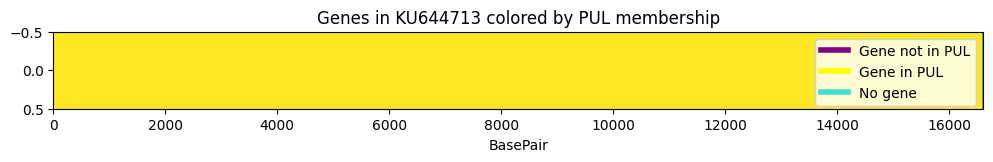

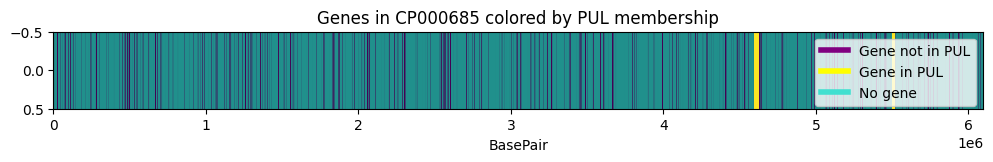

In [20]:
def plot_PULs_in_genome(labeled_table: polars.DataFrame, cluster_table: polars.DataFrame, sequence_id: str):
    # Filter the table for the given sequence_id
    subset = labeled_table.filter(polars.col("sequence_id") == sequence_id)
    subset_puls = cluster_table.filter(polars.col("sequence_id") == sequence_id)
    # get range of genes in PULs for this sequence_id
    contig_range = np.zeros(subset['end'].max(), dtype=int)
    # set locations where genes are to 1
    gene_ranges = [[row[2]+1, row[3]+1] for row in subset.iter_rows()] # NOTE: unsure about off by one errors here, need to check with actual data
    pul_ranges = [[row[2], row[3]] for row in subset_puls.iter_rows()]

    for range in gene_ranges:
        contig_range[range[0]:range[1]] = 1
    
    for range in pul_ranges:
        contig_range[range[0]:range[1]] = 2

    plt.figure(figsize=(12, 1))
    plt.imshow([contig_range], aspect='auto', cmap='viridis', vmin=0, vmax=2)
    plt.title(f"Genes in {sequence_id} colored by PUL membership")
    plt.xlabel("BasePair")
    # add legend
    plt.legend(
        handles=[
            plt.Line2D([0], [0], color='purple', lw=4, label='Gene not in PUL'),
            plt.Line2D([0], [0], color='yellow', lw=4, label='Gene in PUL'),
            plt.Line2D([0], [0], color='turquoise', lw=4, label='No gene'),
        ],
        loc='upper right'
    )
    plt.show()

for sequence_id in genes_with_puls['sequence_id'].unique()[:2]:
    plot_PULs_in_genome(genes_with_puls, cluster_table, sequence_id)

In [ ]:
# create file of unique accession ids from cluster tables
# unique_accessions = cluster_table['sequence_id'].unique().to_frame(name='sequence_id')
# unique_accessions.write_csv('../data/dbCAN-PUL_sequence_ids.tsv', separator='\t')

In [ ]:
# with open('../data/temp_accessed.txt', 'r') as f:
#     ids = f.read().splitlines()

# unique_accessions = polars.read_csv('../data/dbCAN-PUL_sequence_ids.tsv', separator='\t')
# done_ids = [id.split(' ')[3] for id in ids]
# print(len(set(unique_accessions['sequence_id'])))
# print(len(set(done_ids)))
# unprocessed_ids = set(unique_accessions['sequence_id']) - (set(done_ids))

# # save unprocessed ids to file for later use
# with open('../data/temp_unprocessed_ids.tsv', 'w') as f:
#     f.write('sequence_id\n')
#     for id in unprocessed_ids:
#         f.write(f'{id}\n')

In [ ]:
# # save puldb_data_literature
# puldb_data_literature.write_csv('../data/puldb_literature_PULs.tsv', separator='\t')

# # save unique sequence ids for genome search
# unique_sequences = puldb_data_literature['sequence_id'].unique().to_frame(name='sequence_id')
# unique_sequences.write_csv('../data/puldb_literature_sequence_ids.tsv', separator='\t')